# ACTIVIDAD 15 - PERCEPTRÓN ARTIFICIAL

## Introducción

El Perceptrón es uno de los modelos más simples dentro del campo de las Redes Neuronales Artificiales y constituye la base de muchos algoritmos modernos de Inteligencia Artificial y Machine Learning.

Fue desarrollado con el objetivo de simular el comportamiento básico de una neurona biológica. Su función principal es aprender a clasificar datos en diferentes categorías a partir de ejemplos previamente etiquetados.

En esta práctica se implementa un perceptrón simple capaz de determinar si una persona puede ser candidata a obtener una tarjeta de crédito Platinum utilizando dos características:

- Edad.
- Nivel de ahorro.

El modelo aprenderá automáticamente a identificar patrones dentro de los datos para determinar si una solicitud debe ser aprobada o denegada.

---

## Objetivo

Desarrollar e implementar un Perceptrón Artificial Simple utilizando Python y NumPy para comprender el proceso de aprendizaje supervisado, el ajuste de pesos y la clasificación binaria.

---

## Fundamento Teórico

El perceptrón recibe un conjunto de entradas, las multiplica por determinados pesos y posteriormente calcula una suma ponderada.

Matemáticamente se expresa como:

z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

donde:

- x = entradas del modelo.
- w = pesos sinápticos.
- b = sesgo (bias).
- z = resultado de la combinación lineal.

Posteriormente se aplica una función de activación:

f(z) = 1 si z > 0
f(z) = 0 si z ≤ 0

Esta función permite tomar una decisión binaria.

En este ejercicio:

- 1 = Tarjeta aprobada.
- 0 = Tarjeta denegada.

# Importación de Librerías y Definición del Dataset

En esta sección se importan las bibliotecas necesarias para realizar los cálculos matemáticos y la visualización de datos.

## Descripción de los Datos

Cada registro representa una persona mediante dos características:

1. Edad.
2. Nivel de ahorro.

Los valores se encuentran normalizados entre 0 y 1 para facilitar el proceso de aprendizaje.

La variable objetivo denominada **clases** contiene la clasificación deseada:

- 0 → Solicitud denegada.
- 1 → Solicitud aprobada.

Estos datos constituyen el conjunto de entrenamiento del perceptrón.

# Representación Gráfica de los Datos

Antes de entrenar cualquier modelo de Machine Learning es importante visualizar la información.

La gráfica de dispersión permite observar cómo se distribuyen las personas según:

- Edad.
- Ahorro.

Cada punto representa una persona.

## Interpretación

### Clase 0 (Denegada)

Se representa mediante una "X" roja.

Corresponde a personas que no cumplen las condiciones necesarias para obtener la tarjeta Platinum.

### Clase 1 (Aprobada)

Se representa mediante círculos azules.

Corresponde a personas que sí cumplen los requisitos establecidos.

Esta visualización permite comprobar si existe una posible separación entre ambas categorías, condición necesaria para que un perceptrón simple pueda aprender correctamente.

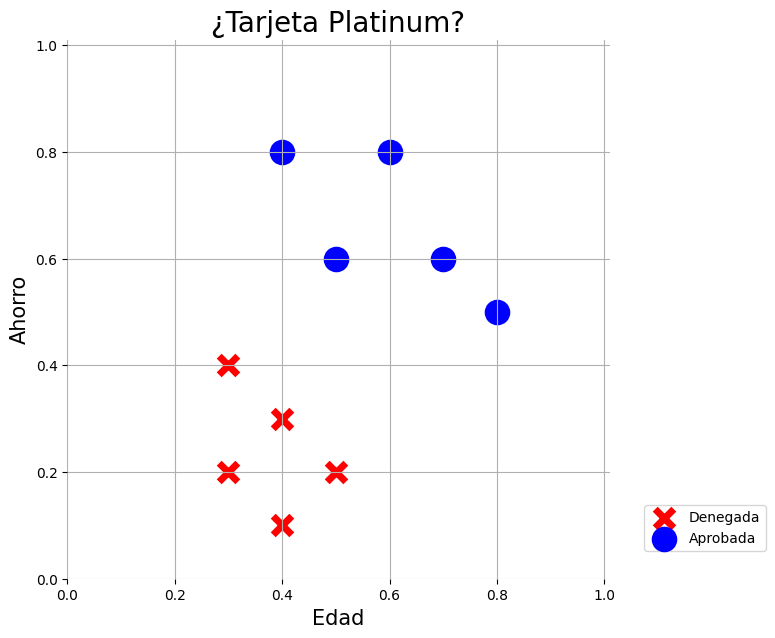

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Datos de 10 personas -> [edad, ahorro]

personas = np.array([[0.3, 0.4], [0.4, 0.3],
                     [0.3, 0.2], [0.4, 0.1],
                     [0.5, 0.2], [0.4, 0.8],
                     [0.6, 0.8], [0.5, 0.6],
                     [0.7, 0.6], [0.8, 0.5]])

# 1: aprobado
# 0: denegado

clases = np.array ([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# Gráfica de dispersión (edad, ahorro)

plt.figure(figsize=(7, 7))
plt.title("¿Tarjeta Platinum?", fontsize=20)
plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")
plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")
plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.grid()
plt.show()

# Implementación de la Función de Activación

La función de activación constituye el mecanismo de decisión del perceptrón.

Su objetivo es transformar una suma numérica en una clasificación binaria.

## Funcionamiento

Primero se calcula la combinación lineal:

z = pesos * entradas

Posteriormente se suma el sesgo (bias):

z + b

Finalmente se toma una decisión:

- Si el resultado es mayor que cero → devuelve 1.
- Si el resultado es menor o igual a cero → devuelve 0.

## Importancia

Esta función representa el comportamiento básico de una neurona artificial.

Gracias a ella, el modelo puede responder preguntas del tipo:

¿La solicitud debe aprobarse?

Sí → 1

No → 0

## Inicialización Aleatoria

Los pesos y el sesgo se inicializan aleatoriamente entre -1 y 1.

Esto permite que el algoritmo comience el proceso de aprendizaje sin conocimientos previos.

In [ ]:
def activacion(pesos, x, b):
  z = pesos * x
  if z.sum() + b > 0:
    return 1
  else:
    return 0

pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)

pesos, b, activacion(pesos, [0.5, 0.5], b)

(array([ 0.9968193 , -0.80990849]), 0.1983379571572792, 1)

# Proceso de Entrenamiento

En esta etapa el perceptrón aprende a clasificar correctamente los datos proporcionados.

## Parámetros Utilizados

### Pesos

Representan la importancia que tiene cada característica dentro de la decisión final.

### Bias (Sesgo)

Permite desplazar la frontera de decisión para mejorar la clasificación.

### Tasa de Aprendizaje

Controla el tamaño de los ajustes realizados durante el entrenamiento.

En este ejercicio:

tasa_de_aprendizaje = 0.01

### Épocas

Una época representa una revisión completa de todos los ejemplos de entrenamiento.

Se utilizan:

epocas = 100

---

## Algoritmo de Aprendizaje

Para cada persona:

1. Se calcula una predicción.
2. Se compara con la respuesta correcta.
3. Se calcula el error.
4. Se ajustan los pesos.
5. Se ajusta el sesgo.

La regla de actualización utilizada es:

peso_nuevo = peso_actual + tasa_aprendizaje × entrada × error

bias_nuevo = bias_actual + tasa_aprendizaje × error

Este procedimiento se repite múltiples veces hasta reducir los errores de clasificación.

---

## Error Total

Durante cada época se calcula el error cuadrático acumulado.

Su propósito es medir qué tan lejos se encuentra el modelo de la solución correcta.

Cuando el error disminuye progresivamente significa que el perceptrón está aprendiendo correctamente los patrones presentes en los datos.

In [ ]:
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)
tasa_de_aprendizaje = 0.01
epocas = 100

for epoca in range(epocas):
  error_total = 0
  for i in range(len(personas)):
      prediccion = activacion(pesos, personas[i], b)
      error = clases[i] - prediccion
      error_total += error**2
      pesos[0] += tasa_de_aprendizaje * personas [i][0] * error
      pesos[1] += tasa_de_aprendizaje * personas [i][1] * error
      b += tasa_de_aprendizaje * error
  print(error_total, end=" ")

activacion(pesos, [0.5, 0.8], b)

5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 2 2 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

1

# Evaluación del Modelo

Una vez concluido el entrenamiento, el perceptrón ya cuenta con pesos ajustados capaces de realizar predicciones sobre nuevos datos.

La instrucción final:

activacion(pesos, [0.5, 0.8], b)

permite evaluar una nueva persona con:

- Edad = 0.5
- Ahorro = 0.8

El resultado será:

- 1 → Tarjeta aprobada.
- 0 → Tarjeta denegada.

Esta predicción se realiza utilizando el conocimiento adquirido durante el entrenamiento.

---

## Conclusiones

El perceptrón es uno de los algoritmos fundamentales de la Inteligencia Artificial.

A través de esta práctica fue posible observar:

- La representación de datos para clasificación.
- El uso de pesos y sesgo.
- El funcionamiento de una función de activación.
- El proceso de aprendizaje supervisado.
- La actualización iterativa de parámetros.
- La generación de predicciones para nuevos datos.

Aunque actualmente existen modelos mucho más complejos, como las Redes Neuronales Profundas (Deep Learning), todos ellos tienen su origen conceptual en el perceptrón simple desarrollado por Rosenblatt.